In [26]:
import os
os.chdir(r"D:\Riphah University\4th semester\Programming of AI\sentiment-lab-68299")
print("Working directory set to:", os.getcwd())

Working directory set to: D:\Riphah University\4th semester\Programming of AI\sentiment-lab-68299


In [27]:
import mlflow
mlflow.set_tracking_uri("sqlite:///mlflow.db")

In [28]:
import nltk

nltk.download('punkt')
nltk.download('stopwords')

import pandas as pd
import json

# load config
config = json.load(open("config.json"))

# load dataset
df = pd.read_csv("data/raw/legal_notices.csv")

df.head(10)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,id,category,label,notice
0,1,C,Regulatory Compliance,FINANCIAL REPORTING NON-COMPLIANCE NOTICE TO: ...
1,2,A,Contract Dispute,NOTICE OF CONTRACT TERMINATION FOR CAUSE TO: C...
2,3,B,Intellectual Property Claim,NOTICE OF PATENT LICENSING OBLIGATION TO: Synt...
3,4,A,Contract Dispute,BREACH OF CONFIDENTIALITY NOTICE TO: Horizon E...
4,5,C,Regulatory Compliance,TELECOMMUNICATIONS LICENCE COMPLIANCE NOTICE T...
5,6,B,Intellectual Property Claim,NOTICE OF SOFTWARE LICENSE VIOLATION TO: Conte...
6,7,C,Regulatory Compliance,CONSUMER PROTECTION COMPLIANCE NOTICE TO: Fast...
7,8,C,Regulatory Compliance,ANTI-MONEY LAUNDERING COMPLIANCE DIRECTIVE TO:...
8,9,B,Intellectual Property Claim,NOTICE OF SOFTWARE LICENSE VIOLATION TO: OpenS...
9,10,C,Regulatory Compliance,CONSUMER PROTECTION COMPLIANCE NOTICE TO: Stre...


In [29]:
# dataset size
print(df.shape)

# missing values check
print(df.isnull().sum())

# check possible target columns
print(df[['category', 'label']].drop_duplicates())

(600, 4)
id          0
category    0
label       0
notice      0
dtype: int64
  category                        label
0        C        Regulatory Compliance
1        A             Contract Dispute
2        B  Intellectual Property Claim


Shape: (600, 4)

Class distribution:
label
Regulatory Compliance          200
Contract Dispute               200
Intellectual Property Claim    200
Name: count, dtype: int64

Missing values:
id          0
category    0
label       0
notice      0
dtype: int64

Average notice length (words): 111.745


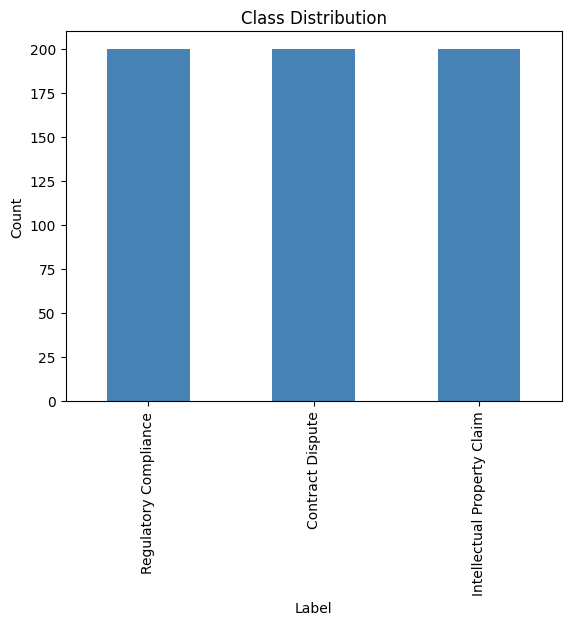

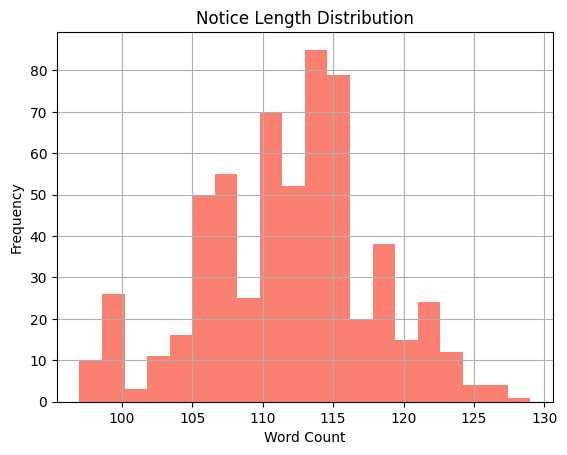

In [30]:
# EDA cell: basic stats and visualizations

import matplotlib.pyplot as plt

# Display basic structure: row count, column count
print("Shape:", df.shape)

# Class distribution: how many notices per category — tells us if classes are balanced
print("\nClass distribution:")
print(df['label'].value_counts())

# Check for missing values in any column — must be reported per Task 2.1
print("\nMissing values:")
print(df.isnull().sum())

# Compute notice length (word count) per row, used for the length histogram
df['text_length'] = df['notice'].str.split().str.len()
print("\nAverage notice length (words):", df['text_length'].mean())

# Plot 1: bar chart of class distribution
df['label'].value_counts().plot(kind='bar', color='steelblue')
plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.savefig("results/class_distribution.png")  # save for report
plt.show()

# Plot 2: histogram of notice lengths
df['text_length'].hist(bins=20, color='salmon')
plt.title("Notice Length Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.savefig("results/length_histogram.png")
plt.show()

In [31]:
# Apply preprocessing
import sys
sys.path.append('src')  # so we can import our custom module
from preprocess import preprocess_text

# Apply the cleaning function to every notice and store result in a new column
df['clean_text'] = df['notice'].apply(preprocess_text)

# Quick sanity check: compare raw vs cleaned text for the first row
print("Raw:", df['notice'].iloc[0])
print("Clean:", df['clean_text'].iloc[0])

Raw: FINANCIAL REPORTING NON-COMPLIANCE NOTICE TO: Global Payment Solutions FROM: Anti-Money Laundering Authority DATE: March 3, 2024 Anti-Money Laundering Authority has determined that Global Payment Solutions has failed to file its quarterly financial disclosure reports as required under Section 7.1 of the Electronic Communications Code 2017. Reports for the periods ending Q2 2024 remain outstanding as of this date. This constitutes a violation of mandatory reporting obligations. Global Payment Solutions is directed to file all outstanding reports within 10 business days. A late filing fee of $15,000 per report will be assessed. Continued non-compliance will result in suspension of Global Payment Solutions's operating license and referral for criminal investigation under applicable statutes.
Clean: financi report noncompli notic global payment solut antimoney launder author date march 3 2024 antimoney launder author determin global payment solut fail file quarterli financi disclosur 

In [32]:
# feature extraction

import sys
sys.path.append('../src')
from features import extract_bow_features, extract_tfidf_features, top_terms_per_class

# Build both feature representations using max_features from config (no hardcoding)
X_bow, bow_vectorizer = extract_bow_features(df['clean_text'], max_features=config['max_features'])
X_tfidf, tfidf_vectorizer = extract_tfidf_features(df['clean_text'], max_features=config['max_features'])

print("BoW shape:", X_bow.shape)
print("TF-IDF shape:", X_tfidf.shape)

# Print top 20 terms per class for TF-IDF (more informative than BoW since it's weighted)
for label in df['label'].unique():
    print(f"\nTop terms for '{label}':")
    print(top_terms_per_class(X_tfidf, tfidf_vectorizer, df['label'], label))

BoW shape: (600, 895)
TF-IDF shape: (600, 895)

Top terms for 'Regulatory Compliance':
[('safeti', 15.292765416590106), ('violat', 13.212723887049574), ('report', 13.065550051680992), ('mandatori', 12.636387518976473), ('submit', 12.510361432329827), ('enforc', 12.38600285722218), ('noncompli', 12.368861307089713), ('complianc', 11.39910306133782), ('ltd', 11.192903045220762), ('regulatori', 10.798451766933852), ('food', 10.5449969543069), ('offic', 10.032049370952155), ('financi', 10.019476466356092), ('per', 9.983123775992583), ('direct', 9.945424332374365), ('protect', 9.895059616517786), ('remedi', 9.76300268934599), ('conduct', 9.661913298411449), ('consum', 9.62731365900435), ('result', 9.610444147279296)]

Top terms for 'Contract Dispute':
[('agreement', 17.237151196559427), ('servic', 12.74673600850501), ('llc', 11.92891654232356), ('section', 11.706771167289675), ('breach', 11.390946299225343), ('notic', 11.223589644145015), ('contract', 11.128916757071865), ('group', 11.01180

In [33]:
# all 4 model-feature combinations

import sys
sys.path.append('../src')
from evaluate import run_experiment
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
import pandas as pd

# Run all 4 required combinations: 2 models x 2 feature types
results = []

results.append(run_experiment(
    X_bow, df['label'],
    MultinomialNB(alpha=config['model_2']['alpha']),
    "NaiveBayes", "BoW", config
))

results.append(run_experiment(
    X_tfidf, df['label'],
    MultinomialNB(alpha=config['model_2']['alpha']),
    "NaiveBayes", "TFIDF", config
))

results.append(run_experiment(
    X_bow, df['label'],
    LogisticRegression(C=config['model_1']['C'], max_iter=config['model_1']['max_iter']),
    "LogReg", "BoW", config
))

results.append(run_experiment(
    X_tfidf, df['label'],
    LogisticRegression(C=config['model_1']['C'], max_iter=config['model_1']['max_iter']),
    "LogReg", "TFIDF", config
))

# Display as a comparison table — this is your Task 5.1 deliverable too
results_df = pd.DataFrame(results)
print(results_df)

        model features  accuracy  precision_macro  recall_macro  f1_macro  \
0  NaiveBayes      BoW       1.0              1.0           1.0       1.0   
1  NaiveBayes    TFIDF       1.0              1.0           1.0       1.0   
2      LogReg      BoW       1.0              1.0           1.0       1.0   
3      LogReg    TFIDF       1.0              1.0           1.0       1.0   

   precision_weighted  recall_weighted  f1_weighted  train_time  infer_time  
0                 1.0              1.0          1.0    0.003277         0.0  
1                 1.0              1.0          1.0    0.001002         0.0  
2                 1.0              1.0          1.0    0.008935         0.0  
3                 1.0              1.0          1.0    0.009373         0.0  


In [34]:
# Run cross-validation: best vs worst" comparison
from sklearn.model_selection import cross_val_score
import numpy as np

cv_results = []

for model_name, model in [("NaiveBayes", MultinomialNB(alpha=config['model_2']['alpha'])),
                           ("LogReg", LogisticRegression(C=config['model_1']['C'], max_iter=config['model_1']['max_iter']))]:
    for feat_name, X in [("BoW", X_bow), ("TFIDF", X_tfidf)]:
        # 5-fold stratified CV gives a more robust estimate than one 80/20 split,
        # especially important here since the single split gave a suspicious perfect score
        scores = cross_val_score(model, X, df['label'], cv=5, scoring='f1_macro')
        cv_results.append({
            "model": model_name,
            "features": feat_name,
            "f1_macro_mean": scores.mean(),
            "f1_macro_std": scores.std()
        })

cv_df = pd.DataFrame(cv_results)
print(cv_df)

        model features  f1_macro_mean  f1_macro_std
0  NaiveBayes      BoW            1.0           0.0
1  NaiveBayes    TFIDF            1.0           0.0
2      LogReg      BoW            1.0           0.0
3      LogReg    TFIDF            1.0           0.0


In [35]:
# MLflow logging for all 4 combinations

import mlflow

# Name the experiment so all runs group together in the MLflow UI
mlflow.set_experiment("legal_notice_classification")

def log_to_mlflow(model_name, feat_name, model_params, metrics, cm_path):
    """Log a single training run's parameters, metrics, and artifacts to MLflow.

    Args:
        model_name (str): e.g. 'LogReg' or 'NaiveBayes'.
        feat_name (str): e.g. 'BoW' or 'TFIDF'.
        model_params (dict): Hyperparameters used for this run.
        metrics (dict): Evaluation metrics from run_experiment().
        cm_path (str): Path to the saved confusion matrix image.
    """
    with mlflow.start_run(run_name=f"{model_name}_{feat_name}"):
        # Log identifying parameters so each run is traceable
        mlflow.log_param("model_type", model_name)
        mlflow.log_param("vectorizer", feat_name)
        mlflow.log_param("random_seed", config['random_seed'])
        mlflow.log_param("max_features", config['max_features'])
        for k, v in model_params.items():
            mlflow.log_param(k, v)

        # Log the metrics required by the exam rubric
        mlflow.log_metric("accuracy", metrics['accuracy'])
        mlflow.log_metric("f1_macro", metrics['f1_macro'])
        mlflow.log_metric("f1_weighted", metrics['f1_weighted'])
        mlflow.log_metric("train_time", metrics['train_time'])

        # Attach the confusion matrix image as an artifact
        mlflow.log_artifact(cm_path)

# Log all 4 base runs using the metrics you already computed in `results`
combos = [
    ("NaiveBayes", "BoW", {"alpha": config['model_2']['alpha']}),
    ("NaiveBayes", "TFIDF", {"alpha": config['model_2']['alpha']}),
    ("LogReg", "BoW", {"C": config['model_1']['C']}),
    ("LogReg", "TFIDF", {"C": config['model_1']['C']}),
]

for (model_name, feat_name, params), metrics in zip(combos, results):
    cm_path = f"results/cm_{model_name}_{feat_name}.png"
    log_to_mlflow(model_name, feat_name, params, metrics, cm_path)

print("Logged 4 base runs to MLflow.")

2026/06/19 12:25:18 INFO mlflow.tracking.fluent: Experiment with name 'legal_notice_classification' does not exist. Creating a new experiment.


Logged 4 base runs to MLflow.


In [36]:
# Hyperparameter sweep (Task 3.3) — varying C for Logistic Regression, also logged

# Sweep over 3+ values of C to satisfy Task 3.3
C_values = [0.01, 0.1, 1.0, 10.0]
sweep_results = []

for C in C_values:
    model = LogisticRegression(C=C, max_iter=config['model_1']['max_iter'])
    metrics = run_experiment(X_tfidf, df['label'], model, "LogReg", f"TFIDF_C{C}", config)
    sweep_results.append({**metrics, "C": C})

    # Log each sweep run to MLflow as well, so total run count exceeds 6
    with mlflow.start_run(run_name=f"LogReg_TFIDF_C{C}"):
        mlflow.log_param("model_type", "LogReg")
        mlflow.log_param("vectorizer", "TFIDF")
        mlflow.log_param("C", C)
        mlflow.log_param("random_seed", config['random_seed'])
        mlflow.log_metric("accuracy", metrics['accuracy'])
        mlflow.log_metric("f1_macro", metrics['f1_macro'])
        mlflow.log_metric("f1_weighted", metrics['f1_weighted'])
        mlflow.log_metric("train_time", metrics['train_time'])
        mlflow.log_artifact(f"results/cm_LogReg_TFIDF_C{C}.png")

sweep_df = pd.DataFrame(sweep_results)
print(sweep_df[["model", "features", "accuracy", "f1_macro", "train_time"]])

    model     features  accuracy  f1_macro  train_time
0  LogReg  TFIDF_C0.01       1.0       1.0    0.005060
1  LogReg   TFIDF_C0.1       1.0       1.0    0.018310
2  LogReg   TFIDF_C1.0       1.0       1.0    0.013708
3  LogReg  TFIDF_C10.0       1.0       1.0    0.014043
